In [3]:
!pip install eptr2 -q
print("eptr2 installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 8.1 MB/s eta 0:00:00
eptr2 installed.


In [4]:
from eptr2 import EPTR2
from google.colab import userdata
import pandas as pd

# Credentials
username = userdata.get('EPIAS_USERNAME')
password = userdata.get('EPIAS_PASSWORD')

# Connect
eptr = EPTR2(username=username, password=password)

# Test: GÖP fiyatları (MCP = Market Clearing Price = PTF)
result = eptr.call("mcp", start_date="2026-03-01", end_date="2026-03-07")

print("Bağlantı başarılı!")
print(result.head(10))
print(f"\nToplam satır: {len(result)}")

Dotenv file not found at .env.
Bağlantı başarılı!
                        date   hour    price  priceUsd  priceEur
0  2026-03-01T00:00:00+03:00  00:00  1650.00     37.67     31.91
1  2026-03-01T01:00:00+03:00  01:00  1417.40     32.36     27.42
2  2026-03-01T02:00:00+03:00  02:00  1417.39     32.36     27.42
3  2026-03-01T03:00:00+03:00  03:00  1400.00     31.96     27.08
4  2026-03-01T04:00:00+03:00  04:00  1650.01     37.67     31.91
5  2026-03-01T05:00:00+03:00  05:00  1899.99     43.38     36.75
6  2026-03-01T06:00:00+03:00  06:00  1989.99     45.43     38.49
7  2026-03-01T07:00:00+03:00  07:00  1449.99     33.10     28.05
8  2026-03-01T08:00:00+03:00  08:00   250.00      5.71      4.84
9  2026-03-01T09:00:00+03:00  09:00    50.00      1.14      0.97

Toplam satır: 168


In [5]:
import matplotlib.pyplot as plt
import time

# 1 yıllık GÖP verisi
result_full = eptr.call("mcp",
                         start_date="2025-04-01",
                         end_date="2026-04-01")

# Temizlik
df_tr = result_full.copy()
df_tr['datetime'] = pd.to_datetime(df_tr['date'])
df_tr['hour']     = df_tr['datetime'].dt.hour
df_tr['month']    = df_tr['datetime'].dt.month
df_tr = df_tr.dropna(subset=['price'])

print(f"Toplam saat     : {len(df_tr)}")
print(f"Min fiyat (TL)  : {df_tr['price'].min():.2f}")
print(f"Max fiyat (TL)  : {df_tr['price'].max():.2f}")
print(f"Ort fiyat (TL)  : {df_tr['price'].mean():.2f}")
print(f"Negatif saat    : {(df_tr['price'] < 0).sum()}")
print(f"\nİlk 5 satır:")
print(df_tr[['datetime','hour','price','priceEur']].head())

Toplam saat     : 8784
Min fiyat (TL)  : 0.00
Max fiyat (TL)  : 3400.00
Ort fiyat (TL)  : 2569.19
Negatif saat    : 0

İlk 5 satır:
                   datetime  hour    price  priceEur
0 2025-04-01 00:00:00+03:00     0  2599.01     63.85
1 2025-04-01 01:00:00+03:00     1  1939.99     47.66
2 2025-04-01 02:00:00+03:00     2  1399.99     34.40
3 2025-04-01 03:00:00+03:00     3  1554.10     38.18
4 2025-04-01 04:00:00+03:00     4   785.45     19.30


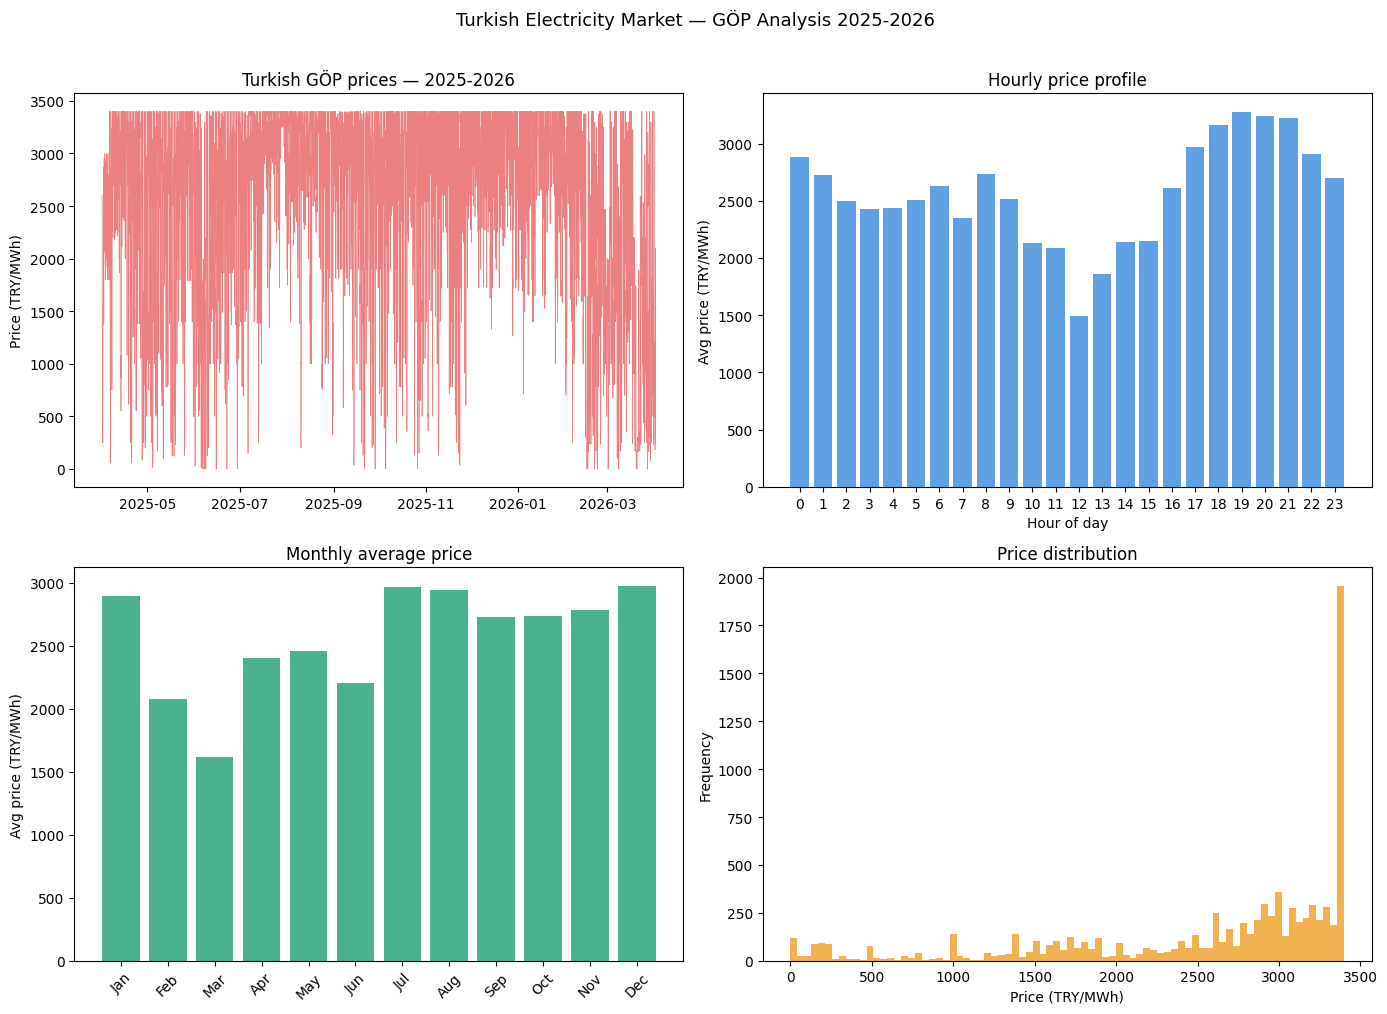

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: fiyat serisi
axes[0,0].plot(df_tr['datetime'], df_tr['price'],
               color='#E24B4A', linewidth=0.5, alpha=0.7)
axes[0,0].set_ylabel('Price (TRY/MWh)')
axes[0,0].set_title('Turkish GÖP prices — 2025-2026')

# Plot 2: saatlik profil
hourly = df_tr.groupby('hour')['price'].mean()
axes[0,1].bar(hourly.index, hourly.values,
              color='#378ADD', alpha=0.8)
axes[0,1].set_xlabel('Hour of day')
axes[0,1].set_ylabel('Avg price (TRY/MWh)')
axes[0,1].set_title('Hourly price profile')
axes[0,1].set_xticks(range(24))

# Plot 3: aylık profil
month_labels = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly = df_tr.groupby('month')['price'].mean()
monthly.index = [month_labels[m] for m in monthly.index]
axes[1,0].bar(monthly.index, monthly.values,
              color='#1D9E75', alpha=0.8)
axes[1,0].set_ylabel('Avg price (TRY/MWh)')
axes[1,0].set_title('Monthly average price')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: fiyat dağılımı
axes[1,1].hist(df_tr['price'], bins=80,
               color='#EF9F27', alpha=0.8, edgecolor='none')
axes[1,1].set_xlabel('Price (TRY/MWh)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Price distribution')

plt.suptitle('Turkish Electricity Market — GÖP Analysis 2025-2026',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# GİP (Gün İçi Piyasa) fiyatları
gip = eptr.call("idm-summary",
                start_date="2025-04-01",
                end_date="2026-04-01")

print(gip.columns.tolist())
print(gip.head())

['kontratAdi', 'kontratTurAciklama', 'maxAlisFiyat', 'minAlisFiyat', 'maxSatisFiyat', 'minSatisFiyat', 'maxEslesmeFiyat', 'minEslesmeFiyat', 'teklifAlisMiktar', 'teklifSatisMiktar', 'eslesmeMiktar', 'islemHacmi', 'agirlikliOrtalama']
   kontratAdi kontratTurAciklama  maxAlisFiyat  minAlisFiyat  maxSatisFiyat  \
0  PH25040100            Saatlik        2599.0           0.0         3089.0   
1  PH25040101            Saatlik        3090.0           1.0         3090.0   
2  PH25040102            Saatlik        3090.0           1.0         3089.9   
3  PH25040103            Saatlik        3090.0           1.0         3090.0   
4  PH25040104            Saatlik        3090.0           1.0         3090.0   

   minSatisFiyat  maxEslesmeFiyat  minEslesmeFiyat  teklifAlisMiktar  \
0          500.1           2599.0            500.1            3846.4   
1          600.0           2120.0            603.0            3734.1   
2            1.0           1400.1            356.8            2922.0   
3  

In [10]:
# GİP verisini düzenle
df_gip = gip.copy()

# Kontrat adından tarih ve saat çıkar
# PH25040100 → 2025-04-01 saat 00
df_gip['year']  = '20' + df_gip['kontratAdi'].str[2:4]
df_gip['month'] = df_gip['kontratAdi'].str[4:6]
df_gip['day']   = df_gip['kontratAdi'].str[6:8]
df_gip['hour']  = df_gip['kontratAdi'].str[8:10].astype(int)
df_gip['date_str'] = df_gip['year'] + '-' + df_gip['month'] + '-' + df_gip['day']
df_gip['datetime']  = pd.to_datetime(df_gip['date_str']) + pd.to_timedelta(df_gip['hour'], unit='h')
df_gip = df_gip.rename(columns={'agirlikliOrtalama': 'gip_price'})
df_gip = df_gip[['datetime','hour','gip_price']].dropna()

# GÖP verisini düzenle
df_gop = df_tr[['datetime','hour','price']].copy()
df_gop = df_gop.rename(columns={'price': 'gop_price'})
df_gop['datetime'] = pd.to_datetime(df_gop['datetime']).dt.tz_localize(None)

# Birleştir
df_spread = df_gop.merge(df_gip, on=['datetime','hour'])
df_spread['spread'] = df_spread['gip_price'] - df_spread['gop_price']
df_spread['month']  = df_spread['datetime'].dt.month

print(f"Toplam saat    : {len(df_spread)}")
print(f"Ort GÖP        : {df_spread['gop_price'].mean():.1f} TL/MWh")
print(f"Ort GİP        : {df_spread['gip_price'].mean():.1f} TL/MWh")
print(f"Ort spread     : {df_spread['spread'].mean():.1f} TL/MWh")
print(f"Pozitif spread : {(df_spread['spread'] > 0).mean()*100:.1f}%")
print(f"Negatif spread : {(df_spread['spread'] < 0).mean()*100:.1f}%")
print(f"\nİlk 5 satır:")
print(df_spread[['datetime','gop_price','gip_price','spread']].head())

Toplam saat    : 8782
Ort GÖP        : 2569.1 TL/MWh
Ort GİP        : 2546.8 TL/MWh
Ort spread     : -22.4 TL/MWh
Pozitif spread : 50.6%
Negatif spread : 49.4%

İlk 5 satır:
             datetime  gop_price    gip_price       spread
0 2025-04-01 00:00:00    2599.01  1518.545799 -1080.464201
1 2025-04-01 01:00:00    1939.99  1196.392359  -743.597641
2 2025-04-01 02:00:00    1399.99   732.721973  -667.268027
3 2025-04-01 03:00:00    1554.10   864.884759  -689.215241
4 2025-04-01 04:00:00     785.45   319.602358  -465.847642


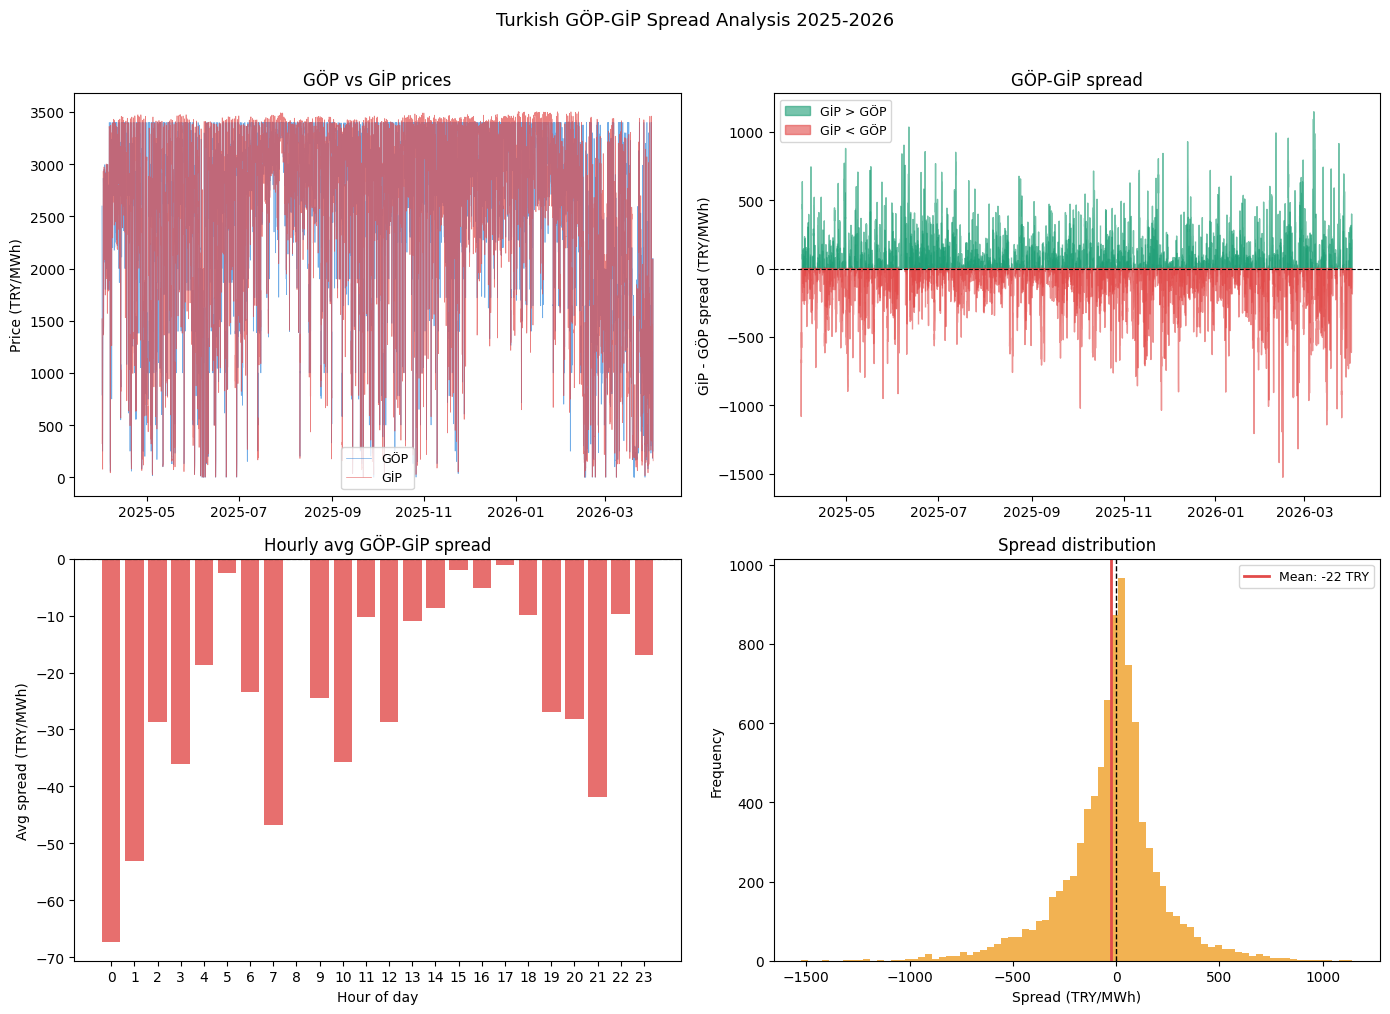

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: GÖP vs GİP fiyat serisi
axes[0,0].plot(df_spread['datetime'], df_spread['gop_price'],
               color='#378ADD', linewidth=0.5, alpha=0.7, label='GÖP')
axes[0,0].plot(df_spread['datetime'], df_spread['gip_price'],
               color='#E24B4A', linewidth=0.5, alpha=0.7, label='GİP')
axes[0,0].set_ylabel('Price (TRY/MWh)')
axes[0,0].set_title('GÖP vs GİP prices')
axes[0,0].legend(fontsize=9)

# Plot 2: spread serisi
axes[0,1].fill_between(df_spread['datetime'], df_spread['spread'],
                       where=(df_spread['spread'] > 0),
                       color='#1D9E75', alpha=0.6, label='GİP > GÖP')
axes[0,1].fill_between(df_spread['datetime'], df_spread['spread'],
                       where=(df_spread['spread'] < 0),
                       color='#E24B4A', alpha=0.6, label='GİP < GÖP')
axes[0,1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0,1].set_ylabel('GİP - GÖP spread (TRY/MWh)')
axes[0,1].set_title('GÖP-GİP spread')
axes[0,1].legend(fontsize=9)

# Plot 3: saatlik ortalama spread
hourly_spread = df_spread.groupby('hour')['spread'].mean()
colors = ['#1D9E75' if s > 0 else '#E24B4A' for s in hourly_spread]
axes[1,0].bar(hourly_spread.index, hourly_spread.values,
              color=colors, alpha=0.8)
axes[1,0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,0].set_xlabel('Hour of day')
axes[1,0].set_ylabel('Avg spread (TRY/MWh)')
axes[1,0].set_title('Hourly avg GÖP-GİP spread')
axes[1,0].set_xticks(range(24))

# Plot 4: spread dağılımı
axes[1,1].hist(df_spread['spread'], bins=80,
               color='#EF9F27', alpha=0.8, edgecolor='none')
axes[1,1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1,1].axvline(df_spread['spread'].mean(),
                  color='#E24B4A', linewidth=2,
                  label=f"Mean: {df_spread['spread'].mean():.0f} TRY")
axes[1,1].set_xlabel('Spread (TRY/MWh)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Spread distribution')
axes[1,1].legend(fontsize=9)

plt.suptitle('Turkish GÖP-GİP Spread Analysis 2025-2026',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# Saatlik PTF istatistikleri — teklif rehberi
hourly_stats = df_tr.groupby('hour')['price'].agg([
    'mean',
    'std',
    ('alt_25', lambda x: x.quantile(0.25)),
    ('ust_75', lambda x: x.quantile(0.75)),
    ('min',    'min'),
    ('max',    'max'),
]).round(0)

print("── Saatlik PTF istatistikleri — teklif rehberi ──────")
print(f"{'Saat':>5} {'Ort':>8} {'Std':>8} {'Alt 25%':>8} {'Üst 75%':>8} {'Min':>8} {'Max':>8}")
print("-" * 60)
for hour, row in hourly_stats.iterrows():
    print(f"{hour:>5} {row['mean']:>8.0f} {row['std']:>8.0f} "
          f"{row['alt_25']:>8.0f} {row['ust_75']:>8.0f} "
          f"{row['min']:>8.0f} {row['max']:>8.0f}")

── Saatlik PTF istatistikleri — teklif rehberi ──────
 Saat      Ort      Std  Alt 25%  Üst 75%      Min      Max
------------------------------------------------------------
    0     2885      653     2900     3287        0     3400
    1     2722      701     2600     3180        0     3400
    2     2501      741     2213     2977        0     3400
    3     2431      742     2000     2933        0     3400
    4     2437      728     2000     2925        0     3400
    5     2505      696     2236     2948        0     3400
    6     2628      740     2350     3145      165     3400
    7     2351      933     1744     3138       50     3400
    8     2732      981     2473     3400        0     3400
    9     2517     1055     1798     3399        0     3400
   10     2132     1101     1395     3130        0     3400
   11     2086     1079     1400     2992        0     3400
   12     1497      978      715     2359        0     3400
   13     1863     1016     1200     2777    

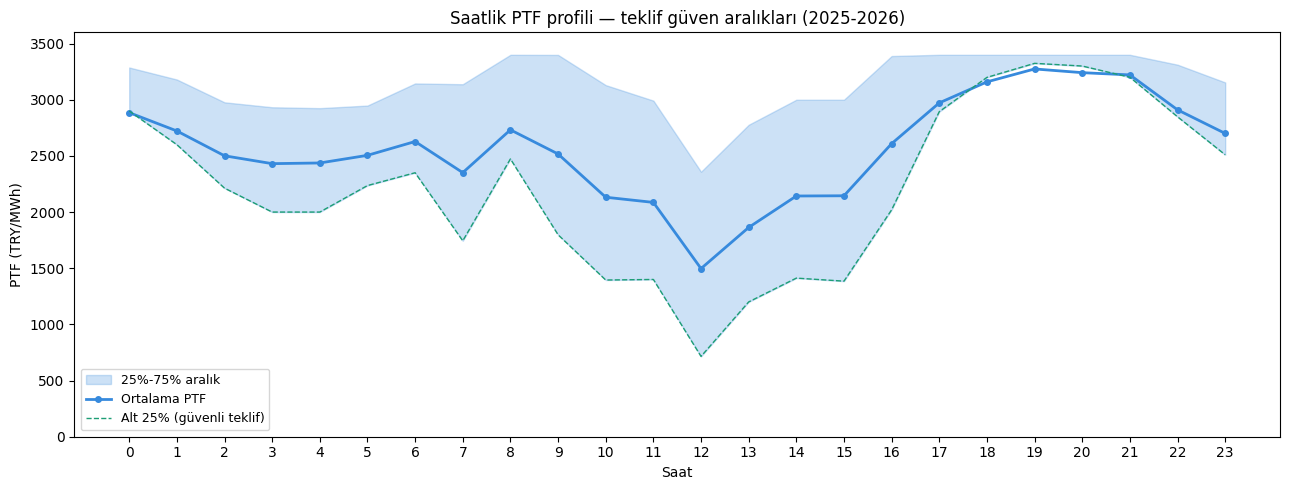

Teklif rehberi:
Yeşil çizgi = güvenli teklif seviyesi (zamanın %75'inde kabul)


In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(13, 5))

hours = hourly_stats.index
means = hourly_stats['mean'].values
q25   = hourly_stats['alt_25'].values
q75   = hourly_stats['ust_75'].values

ax.fill_between(hours, q25, q75,
                alpha=0.25, color='#378ADD', label='25%-75% aralık')
ax.plot(hours, means, color='#378ADD',
        linewidth=2, marker='o', markersize=4, label='Ortalama PTF')
ax.plot(hours, q25, color='#1D9E75',
        linewidth=1, linestyle='--', label='Alt 25% (güvenli teklif)')

ax.set_xlabel('Saat')
ax.set_ylabel('PTF (TRY/MWh)')
ax.set_title('Saatlik PTF profili — teklif güven aralıkları (2025-2026)')
ax.set_xticks(range(24))
ax.legend(fontsize=9)
ax.set_ylim(0, 3600)
plt.tight_layout()
plt.show()

print("Teklif rehberi:")
print("Yeşil çizgi = güvenli teklif seviyesi (zamanın %75'inde kabul)")

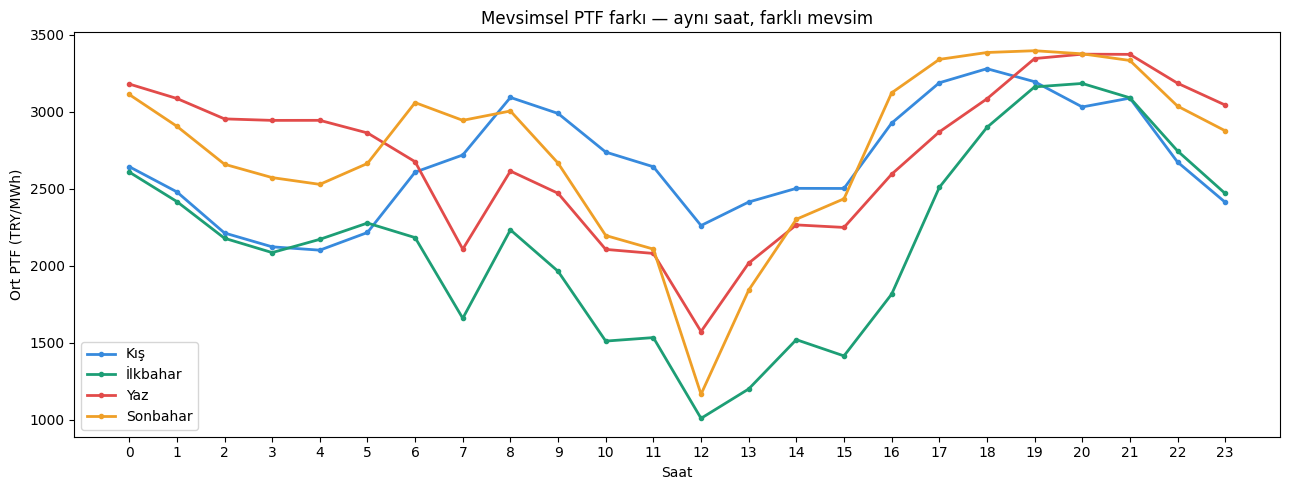

In [17]:
# Yaz vs kış PTF karşılaştırması
df_tr['season'] = df_tr['month'].map({
    12:'Kış', 1:'Kış', 2:'Kış',
    3:'İlkbahar', 4:'İlkbahar', 5:'İlkbahar',
    6:'Yaz', 7:'Yaz', 8:'Yaz',
    9:'Sonbahar', 10:'Sonbahar', 11:'Sonbahar'
})

seasonal = df_tr.groupby(['season','hour'])['price'].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(13, 5))
colors = {'Kış':'#378ADD', 'İlkbahar':'#1D9E75',
          'Yaz':'#E24B4A', 'Sonbahar':'#EF9F27'}

for season in ['Kış','İlkbahar','Yaz','Sonbahar']:
    if season in seasonal.columns:
        ax.plot(seasonal.index, seasonal[season],
                linewidth=2, marker='o', markersize=3,
                color=colors[season], label=season)

ax.set_xlabel('Saat')
ax.set_ylabel('Ort PTF (TRY/MWh)')
ax.set_title('Mevsimsel PTF farkı — aynı saat, farklı mevsim')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()